# **Project 2: Flower Classifier**
**Task 4: Prepare the Data (Split into Train/Test)**
-----------------------------------------------------------
Goal: Load the Iris dataset, explore it, separate features (measurements)
from labels (species), and split into training/testing sets.

The Iris dataset has 150 flowers, each with 4 measurements:
sepal length, sepal width, petal length, petal width (all in cm),
and a species label: 0 = setosa, 1 = versicolor, 2 = virginica.

This script saves the train/test split to CSV files so Task 5 and
Task 6 can reuse the exact same split (important — using a different
split each time would make accuracy comparisons across tasks unfair).
"""

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [2]:
# ---------------------------------------------------------
# Step 1: Load the Iris dataset
# ---------------------------------------------------------
iris = load_iris()

# Build a readable DataFrame to explore (features + species name)
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species_id"] = iris.target
df["species_name"] = df["species_id"].map(
    {i: name for i, name in enumerate(iris.target_names)}
)

In [3]:
# ---------------------------------------------------------
# Step 2: Explore the data
# ---------------------------------------------------------
print("First 5 rows:")
print(df.head())

print("\nDataset shape (rows, columns):", df.shape)

print("\nHow many flowers per species:")
print(df["species_name"].value_counts())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nFeature statistics:")
print(df.describe())

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  
3           0       setosa  
4           0       setosa  

Dataset shape (rows, columns): (150, 6)

How many flowers per species:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species_name         0
dtype: in

In [4]:
# ---------------------------------------------------------
# Step 3: Separate features (X) from labels (y)
# ---------------------------------------------------------
X = iris.data          # 4 measurements per flower
y = iris.target        # species id (0, 1, or 2)

In [5]:
# ---------------------------------------------------------
# Step 4: Split into training (70%) and testing (30%) sets
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

print(f"\nTotal samples: {len(X)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


Total samples: 150
Training samples: 105
Test samples: 45


In [6]:
# ---------------------------------------------------------
# Step 5: Save the split so Task 5 and Task 6 can reuse it
# ---------------------------------------------------------
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

train_df = pd.DataFrame(X_train, columns=feature_cols)
train_df["species_id"] = y_train
train_df.to_csv("iris_train.csv", index=False)

test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df["species_id"] = y_test
test_df.to_csv("iris_test.csv", index=False)

# Save species names too (0/1/2 -> setosa/versicolor/virginica)
species_map = pd.DataFrame({
    "species_id": list(range(len(iris.target_names))),
    "species_name": iris.target_names
})
species_map.to_csv("species_names.csv", index=False)

print("\nSaved 'iris_train.csv', 'iris_test.csv', and 'species_names.csv'.")
print("Task 5 will load these to train the k-NN classifier.")



Saved 'iris_train.csv', 'iris_test.csv', and 'species_names.csv'.
Task 5 will load these to train the k-NN classifier.


**Task 5: Train a k-Nearest Neighbors (k-NN) Classifier**
-----------------------------------------------------------
Goal: Load the train/test split from Task 4 and train a k-NN
classifier that predicts a flower's species from its measurements.

How k-NN works: for a new flower, it measures the distance to every
flower in the training set, finds the "k" closest ones, and predicts
the species that appears most often among those neighbors.

Requires: 'iris_train.csv', 'iris_test.csv', and 'species_names.csv'
(all created by task4_prepare_data.py) must be in the same folder.

This script saves the trained (unscaled) model and its predictions
so Task 6 can compare against a scaled version without retraining
from scratch.

In [7]:
import pandas as pd
import joblib
from sklearn.neighbors import KNeighborsClassifier

In [8]:
# ---------------------------------------------------------
# Step 1: Load the train/test split produced by Task 4
# ---------------------------------------------------------
train_df = pd.read_csv("iris_train.csv")
test_df = pd.read_csv("iris_test.csv")
species_map = pd.read_csv("species_names.csv")

feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

X_train = train_df[feature_cols]
y_train = train_df["species_id"]
X_test = test_df[feature_cols]
y_test = test_df["species_id"]

print(f"Loaded {len(X_train)} training flowers and {len(X_test)} test flowers.")

Loaded 105 training flowers and 45 test flowers.


In [9]:
# ---------------------------------------------------------
# Step 2: Create and train the k-NN classifier (k = 3)
# ---------------------------------------------------------
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [10]:
# ---------------------------------------------------------
# Step 3: Predict on the test set and check accuracy
# ---------------------------------------------------------
y_pred = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)

print(f"\nk-NN model trained with k={k} neighbors.")
print(f"Test accuracy (unscaled features): {accuracy * 100:.2f}%")


k-NN model trained with k=3 neighbors.
Test accuracy (unscaled features): 97.78%


In [11]:
# ---------------------------------------------------------
# Step 4: Show a few example predictions
# ---------------------------------------------------------
name_lookup = dict(zip(species_map["species_id"], species_map["species_name"]))

preview = test_df[feature_cols].copy()
preview["Actual"] = test_df["species_id"].map(name_lookup)
preview["Predicted"] = pd.Series(y_pred).map(name_lookup)
preview["Correct"] = preview["Actual"] == preview["Predicted"]

print("\nSample predictions (first 10 test flowers):")
print(preview.head(10).to_string(index=False))


Sample predictions (first 10 test flowers):
 sepal_length  sepal_width  petal_length  petal_width     Actual  Predicted  Correct
          6.2          3.4           5.4          2.3  virginica  virginica     True
          5.4          3.9           1.7          0.4     setosa     setosa     True
          4.6          3.4           1.4          0.3     setosa     setosa     True
          4.9          2.5           4.5          1.7  virginica versicolor    False
          6.6          3.0           4.4          1.4 versicolor versicolor     True
          6.1          2.8           4.0          1.3 versicolor versicolor     True
          6.7          2.5           5.8          1.8  virginica  virginica     True
          6.2          2.2           4.5          1.5 versicolor versicolor     True
          6.4          2.7           5.3          1.9  virginica  virginica     True
          5.4          3.9           1.3          0.4     setosa     setosa     True


In [12]:
# ---------------------------------------------------------
# Step 5: Save the model and predictions for Task 6
# ---------------------------------------------------------
joblib.dump(knn, "knn_unscaled_model.pkl")

results_df = test_df[feature_cols + ["species_id"]].copy()
results_df["predicted_id"] = y_pred
results_df.to_csv("knn_unscaled_predictions.csv", index=False)

with open("unscaled_accuracy.txt", "w") as f:
    f.write(str(accuracy))

print("\nModel saved to 'knn_unscaled_model.pkl'.")
print("Predictions saved to 'knn_unscaled_predictions.csv'.")
print("Task 6 will use this as a baseline to compare against scaled features.")


Model saved to 'knn_unscaled_model.pkl'.
Predictions saved to 'knn_unscaled_predictions.csv'.
Task 6 will use this as a baseline to compare against scaled features.


**Task 6: Improve the Model with Feature Scaling and Evaluation**
-----------------------------------------------------------
Goal: Scale the 4 measurements to a common 0-1 range, retrain the
k-NN classifier, and compare its accuracy against the unscaled
baseline from Task 5. Then look deeper with a classification
report and confusion matrix, and visualize the results.

Why scaling matters: k-NN decides "closeness" using distance.
Petal length ranges roughly 1-7 cm while sepal width ranges roughly
2-4.4 cm, so without scaling, the feature with the larger range can
dominate the distance calculation. MinMaxScaler rescales every
feature to 0-1 so each one contributes fairly.

Requires: 'iris_train.csv', 'iris_test.csv', 'species_names.csv',
and 'unscaled_accuracy.txt' (all created by Task 4 / Task 5) must be
in the same folder.

In [13]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [14]:
# ---------------------------------------------------------
# Step 1: Load the same train/test split used in Task 4 & 5
# ---------------------------------------------------------
train_df = pd.read_csv("iris_train.csv")
test_df = pd.read_csv("iris_test.csv")
species_map = pd.read_csv("species_names.csv")

feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
target_names = species_map["species_name"].tolist()

X_train = train_df[feature_cols]
y_train = train_df["species_id"]
X_test = test_df[feature_cols]
y_test = test_df["species_id"]

with open("unscaled_accuracy.txt") as f:
    unscaled_accuracy = float(f.read())

print(f"Baseline (unscaled) accuracy from Task 5: {unscaled_accuracy * 100:.2f}%")

Baseline (unscaled) accuracy from Task 5: 97.78%


In [15]:
# ---------------------------------------------------------
# Step 2: Scale features to a 0-1 range
# ---------------------------------------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use the SAME scaling as training

In [16]:
# ---------------------------------------------------------
# Step 3: Train a new k-NN model on the scaled features
# ---------------------------------------------------------
k = 3
knn_scaled = KNeighborsClassifier(n_neighbors=k)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
scaled_accuracy = knn_scaled.score(X_test_scaled, y_test)

print(f"New (scaled) accuracy: {scaled_accuracy * 100:.2f}%")

improvement = (scaled_accuracy - unscaled_accuracy) * 100
if improvement > 0:
    print(f"Scaling improved accuracy by {improvement:.2f} percentage points.")
elif improvement < 0:
    print(f"Scaling decreased accuracy by {abs(improvement):.2f} percentage points "
          f"(iris features are already on similar scales, so this can happen).")
else:
    print("Scaling made no difference for this split.")

New (scaled) accuracy: 97.78%
Scaling made no difference for this split.


In [17]:
# ---------------------------------------------------------
# Step 4: Detailed evaluation - classification report
# ---------------------------------------------------------
print("\nClassification Report (scaled model):")
print(classification_report(y_test, y_pred_scaled, target_names=target_names))


Classification Report (scaled model):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [18]:
# ---------------------------------------------------------
# Step 5: Confusion matrix - which species get confused?
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_scaled)
print("Confusion Matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm, index=target_names, columns=target_names))

Confusion Matrix (rows = actual, columns = predicted):
            setosa  versicolor  virginica
setosa          15           0          0
versicolor       0          15          0
virginica        0           1         14


In [19]:
# ---------------------------------------------------------
# Step 6: Save the scaled model, scaler, and results
# ---------------------------------------------------------
joblib.dump(knn_scaled, "knn_scaled_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

summary = pd.DataFrame({
    "Model": ["Unscaled k-NN", "Scaled k-NN"],
    "Accuracy (%)": [round(unscaled_accuracy * 100, 2), round(scaled_accuracy * 100, 2)]
})
summary.to_csv("accuracy_comparison.csv", index=False)
print("\nAccuracy comparison saved to 'accuracy_comparison.csv'.")


Accuracy comparison saved to 'accuracy_comparison.csv'.


Evaluation plot saved to 'knn_evaluation_plot.png'.


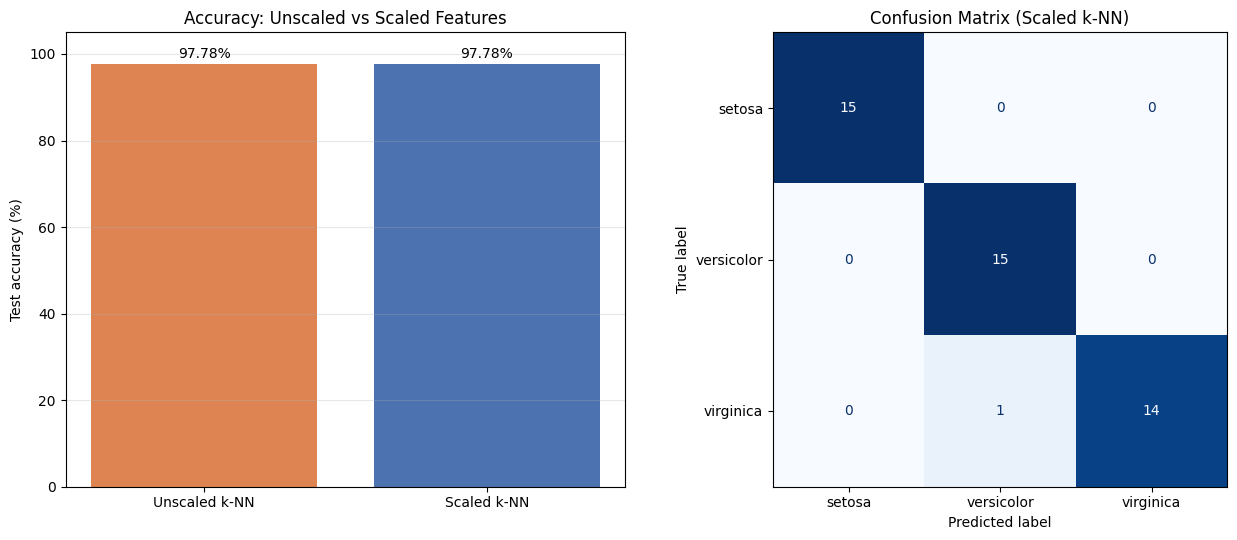

In [20]:
# ---------------------------------------------------------
# Step 7: Visualize - accuracy comparison + confusion matrix
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: bar chart comparing unscaled vs scaled accuracy
bars = axes[0].bar(
    ["Unscaled k-NN", "Scaled k-NN"],
    [unscaled_accuracy * 100, scaled_accuracy * 100],
    color=["#DD8452", "#4C72B0"]
)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel("Test accuracy (%)")
axes[0].set_title("Accuracy: Unscaled vs Scaled Features")
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f"{height:.2f}%", xy=(bar.get_x() + bar.get_width() / 2, height),
                      xytext=(0, 4), textcoords="offset points", ha="center")
axes[0].grid(axis="y", alpha=0.3)

# Right: confusion matrix for the scaled model
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix (Scaled k-NN)")

plt.tight_layout()
plot_path = "knn_evaluation_plot.png"
plt.savefig(plot_path, dpi=150)
print(f"Evaluation plot saved to '{plot_path}'.")